# Green BPM Guideline Survey — Analysis

Loads every `guidelines/<source>/guidelines.csv` (raw guideline data) and `survey_claude.csv`
(Claude-generated BPM relevance ratings) across all sources, and explores the results.

The human interview pass (`survey.csv`) is currently empty for every source — the last section
of this notebook is a comparison stub that will activate once real ratings are filled in.

**Sources:**
- `aws`, `azure`, `gcp` — cloud vendor Well-Architected sustainability pillars
- `gsf` — Green Software Foundation Patterns Catalog
- `w3c` — W3C Web Sustainability Guidelines
- `gbpp` — Green Business Process Patterns (Nowak et al., PLoP 2011) — BPM-native
- `ppatterns` — process-pattern.app, Sustainability-tagged patterns — BPM-native
- `lean` — Lean and Environment (EPA Lean & Environment Toolkit; Lean Enterprise Institute) — BPM-native


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

REPO_ROOT = Path.cwd()
GUIDELINES_DIR = REPO_ROOT / "guidelines"

SOURCES = ["aws", "azure", "gcp", "gsf", "w3c", "gbpp", "ppatterns", "lean"]
BPM_NATIVE = {"gbpp", "ppatterns", "lean"}


## Load and merge all sources

In [2]:
def load_source(source):
    g_path = GUIDELINES_DIR / source / "guidelines.csv"
    s_path = GUIDELINES_DIR / source / "survey_claude.csv"

    guidelines = pd.read_csv(g_path, encoding="utf-8-sig")
    survey = pd.read_csv(s_path, encoding="utf-8-sig")

    merged = guidelines.merge(survey, on="ID", how="left", validate="one_to_one")
    merged.insert(0, "Source", source)
    merged["BPM Native"] = source in BPM_NATIVE
    return merged

frames = [load_source(s) for s in SOURCES]
df = pd.concat(frames, ignore_index=True)

# BPM Relevance / Generic come in as object dtype where any row is NaN; coerce explicitly
df["BPM Relevance"] = pd.to_numeric(df["BPM Relevance"], errors="coerce")

print(f"Loaded {len(df)} guidelines across {df['Source'].nunique()} sources")
df.head()


Loaded 425 guidelines across 8 sources


,Source,ID,Name,Category,Reference,Guideline,RespondentID,BPM Relevance,BPM Scope,Generic,BPM Justification,BPM Lifecycle,Discussion,BPM Native
0,aws,AWS.Region.1,Choose Region based on both business requirements and sustainability goals,Region Selection,https://docs.aws.amazon.com/wellarchitected/latest/sustainability-pillar/sus...,Choose a Region for your workload based on both your business requirements a...,claude,3,Infrastructure/Platform,Yes,Where the process engine and its workers are hosted directly shapes the carb...,Execution,NaN,False
1,aws,AWS.Demand.1,Scale workload infrastructure dynamically,Alignment to demand,https://docs.aws.amazon.com/wellarchitected/latest/sustainability-pillar/sus...,Use elasticity of the cloud and scale your infrastructure dynamically to mat...,claude,3,"Worker/Task, Infrastructure/Platform",No,Scaling worker capacity dynamically to match the rate of incoming process in...,Execution,NaN,False
2,aws,AWS.Demand.2,Align SLAs with sustainability goals,Alignment to demand,https://docs.aws.amazon.com/wellarchitected/latest/sustainability-pillar/sus...,Review and optimize workload service-level agreements (SLA) based on your su...,claude,3,Organizational/Governance,No,SLAs such as response times or completion deadlines are frequently encoded d...,Design,NaN,False
3,aws,AWS.Demand.3,Stop the creation and maintenance of unused\r\n assets,Alignment to demand,https://docs.aws.amazon.com/wellarchitected/latest/sustainability-pillar/sus...,Decommission unused assets in your workload to reduce the number of cloud re...,claude,1,Infrastructure/Platform,Yes,Generic resource hygiene (decommissioning unused cloud assets) with no parti...,Not Applicable,NaN,False
4,aws,AWS.Demand.4,Optimize geographic placement of workloads based on their networking require...,Alignment to demand,https://docs.aws.amazon.com/wellarchitected/latest/sustainability-pillar/sus...,Select cloud location and services for your workload that reduce the distanc...,claude,1,Infrastructure/Platform,Yes,Placing services closer together to cut network hops could marginally affect...,Not Applicable,NaN,False


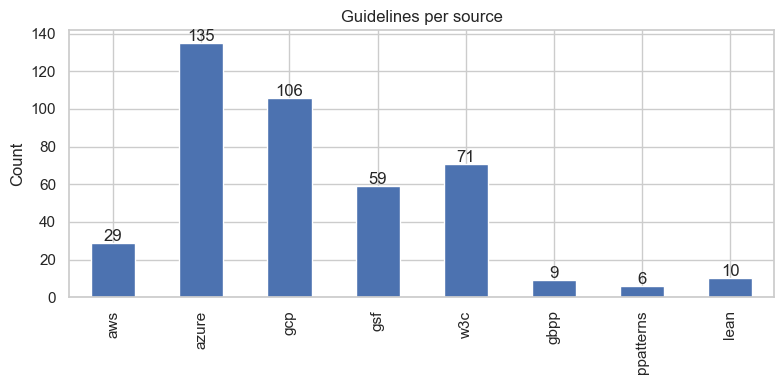

In [3]:
counts = df.groupby("Source").size().reindex(SOURCES)
ax = counts.plot(kind="bar", figsize=(8, 4), color="#4C72B0")
ax.set_title("Guidelines per source")
ax.set_ylabel("Count")
ax.set_xlabel("")
for i, v in enumerate(counts):
    ax.text(i, v + 1, str(v), ha="center")
plt.tight_layout()
plt.show()


## BPM Relevance distribution

`BPM Relevance` is a 0–3 scale (see `SURVEY_SCHEMA.md`): 0 = not relevant to BPM at all,
3 = directly and obviously relevant.

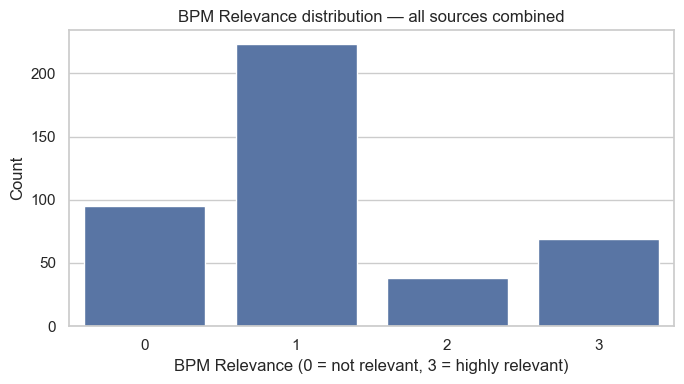

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x="BPM Relevance", order=[0, 1, 2, 3], color="#4C72B0", ax=ax)
ax.set_title("BPM Relevance distribution — all sources combined")
ax.set_xlabel("BPM Relevance (0 = not relevant, 3 = highly relevant)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

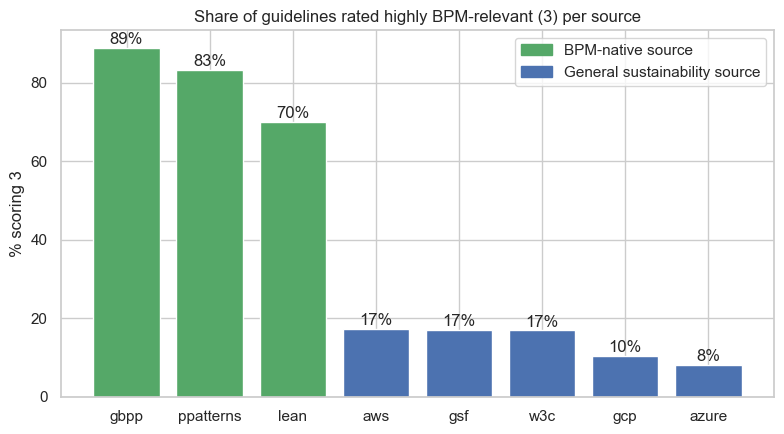

In [5]:
# % of guidelines scoring 3 ("highly relevant") per source, ordered high to low
high_share = (
    df.assign(high=df["BPM Relevance"] >= 3)
    .groupby("Source")["high"]
    .mean()
    .mul(100)
    .reindex(SOURCES)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#55A868" if s in BPM_NATIVE else "#4C72B0" for s in high_share.index]
bars = ax.bar(high_share.index, high_share.values, color=colors)
ax.set_title("Share of guidelines rated highly BPM-relevant (3) per source")
ax.set_ylabel("% scoring 3")
for bar, v in zip(bars, high_share.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1, f"{v:.0f}%", ha="center")
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color="#55A868", label="BPM-native source"),
        plt.Rectangle((0, 0), 1, 1, color="#4C72B0", label="General sustainability source"),
    ]
)
plt.tight_layout()
plt.show()

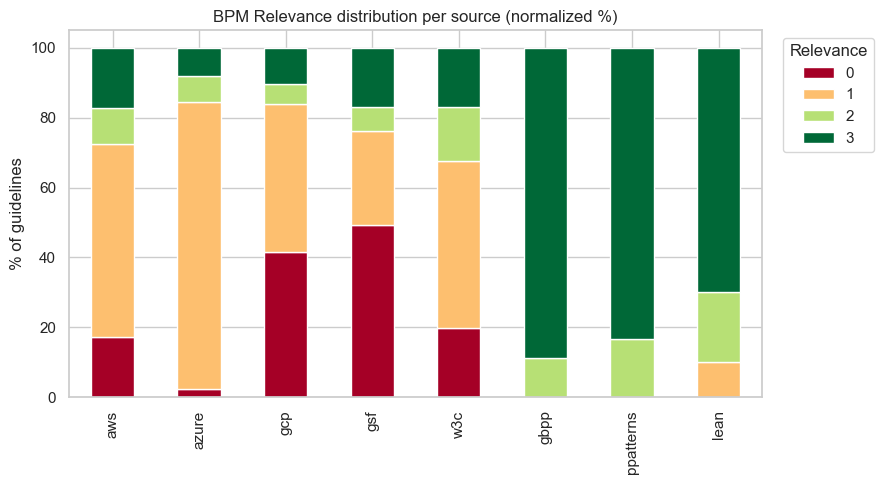

In [6]:
# Full relevance distribution per source, normalized to %, stacked
dist = (
    pd.crosstab(df["Source"], df["BPM Relevance"], normalize="index")
    .mul(100)
    .reindex(SOURCES)
)
dist = dist.reindex(columns=[0, 1, 2, 3], fill_value=0)

ax = dist.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="RdYlGn")
ax.set_title("BPM Relevance distribution per source (normalized %)")
ax.set_ylabel("% of guidelines")
ax.set_xlabel("")
ax.legend(title="Relevance", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## BPM Scope

54 guideline(s) touch more than one scope and are counted once per scope below (percentages/counts can exceed the row total).


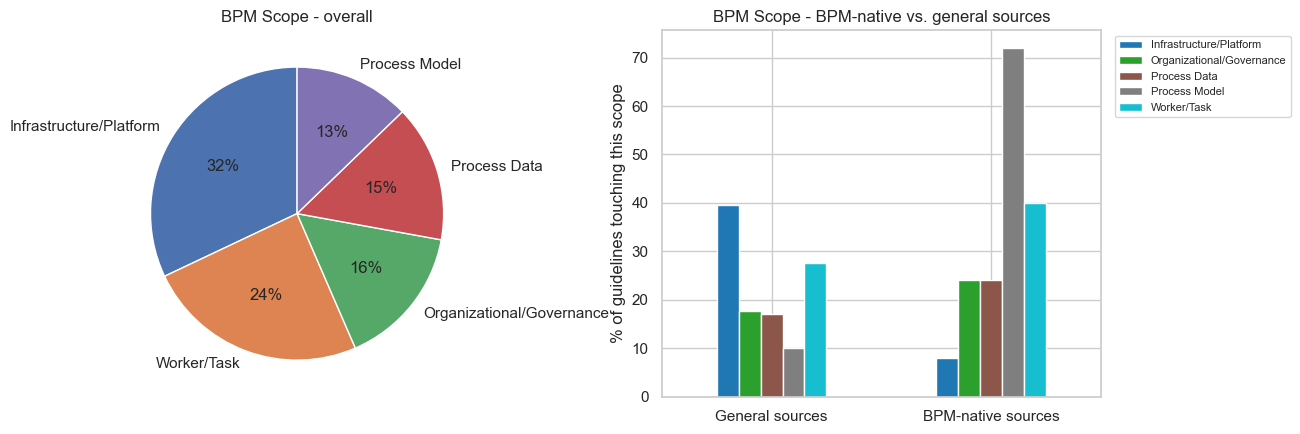

In [7]:
# BPM Scope is multi-select (comma-separated) - explode so a guideline touching
# multiple layers counts toward each one, instead of forming its own composite category.
scope_exploded = (
    df.dropna(subset=["BPM Scope"])
    .assign(**{"BPM Scope": df["BPM Scope"].str.split(",")})
    .explode("BPM Scope")
)
scope_exploded["BPM Scope"] = scope_exploded["BPM Scope"].str.strip()
print(f"{(df['BPM Scope'].str.contains(',')).sum()} guideline(s) touch more than one scope "
      f"and are counted once per scope below (percentages/counts can exceed the row total).")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

scope_counts = scope_exploded["BPM Scope"].value_counts()
axes[0].pie(scope_counts.values, labels=scope_counts.index, autopct="%1.0f%%", startangle=90)
axes[0].set_title("BPM Scope - overall")

scope_by_native = (
    pd.crosstab(scope_exploded["BPM Native"], scope_exploded["BPM Scope"]).apply(
        lambda row: row / df.loc[df["BPM Native"] == row.name, "BPM Scope"].notna().sum() * 100, axis=1
    )
)
scope_by_native.index = ["General sources", "BPM-native sources"]
scope_by_native.plot(kind="bar", stacked=False, ax=axes[1], colormap="tab10")
axes[1].set_title("BPM Scope - BPM-native vs. general sources")
axes[1].set_ylabel("% of guidelines touching this scope")
axes[1].set_xlabel("")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.setp(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## Generic vs. BPM-specific

95 guideline(s) excluded (Generic not applicable at BPM Relevance = 0)


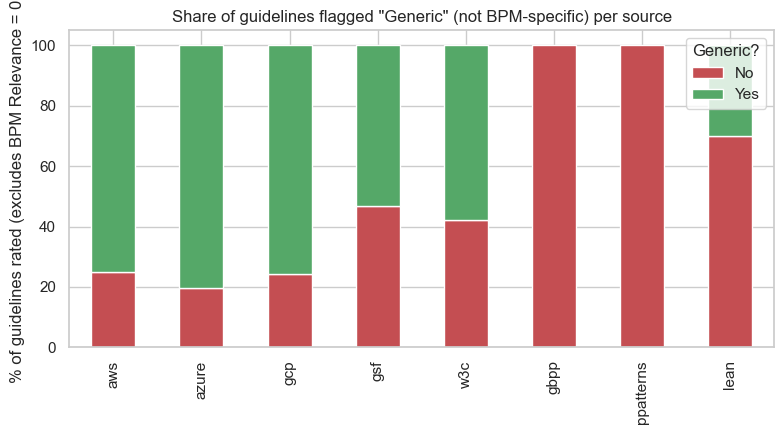

In [8]:
# Generic is blank/N-A for guidelines rated 0 on BPM Relevance (see SURVEY_SCHEMA.md) -
# exclude those before charting so "not applicable" doesn't get silently folded into a color.
# (pandas reads empty CSV cells as NaN, not "", so filter on notna())
rated = df[df["Generic"].notna() & (df["Generic"] != "")]
excluded = len(df) - len(rated)
print(f"{excluded} guideline(s) excluded (Generic not applicable at BPM Relevance = 0)")

generic_share = (
    pd.crosstab(rated["Source"], rated["Generic"], normalize="index").mul(100).reindex(SOURCES)
)
ax = generic_share.plot(kind="bar", stacked=True, figsize=(8, 4.5), color=["#C44E52", "#55A868"])
ax.set_title('Share of guidelines flagged "Generic" (not BPM-specific) per source')
ax.set_ylabel("% of guidelines rated (excludes BPM Relevance = 0)")
ax.set_xlabel("")
ax.legend(title="Generic?")
plt.tight_layout()
plt.show()

## BPM Lifecycle coverage

`BPM Lifecycle` is a multi-select field (comma-separated), so it's exploded into one row per
phase before counting.


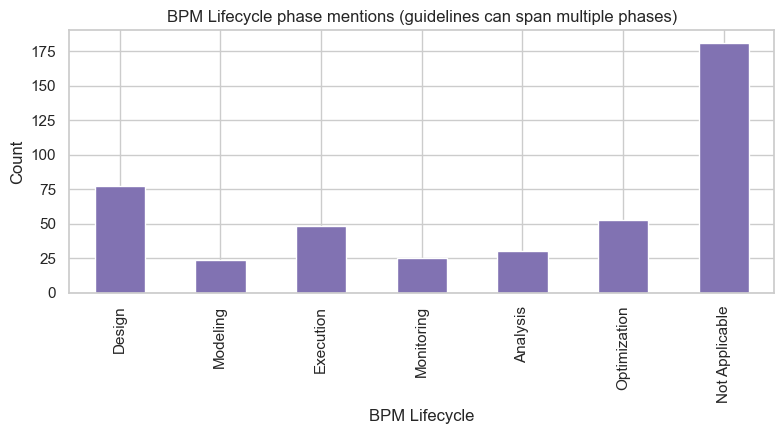

In [9]:
lifecycle_exploded = (
    df.dropna(subset=["BPM Lifecycle"])
    .assign(**{"BPM Lifecycle": df["BPM Lifecycle"].str.split(",")})
    .explode("BPM Lifecycle")
)
lifecycle_exploded["BPM Lifecycle"] = lifecycle_exploded["BPM Lifecycle"].str.strip()

phase_order = ["Design", "Modeling", "Execution", "Monitoring", "Analysis", "Optimization", "Not Applicable"]
phase_counts = lifecycle_exploded["BPM Lifecycle"].value_counts().reindex(phase_order, fill_value=0)

ax = phase_counts.plot(kind="bar", figsize=(8, 4.5), color="#8172B2")
ax.set_title("BPM Lifecycle phase mentions (guidelines can span multiple phases)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## Relevance by Scope

C:\Users\KálmánKépes\AppData\Local\Temp\ipykernel_26644\2961769282.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scope_exploded, x="BPM Scope", y="BPM Relevance", order=order, ax=ax, palette="Set2")


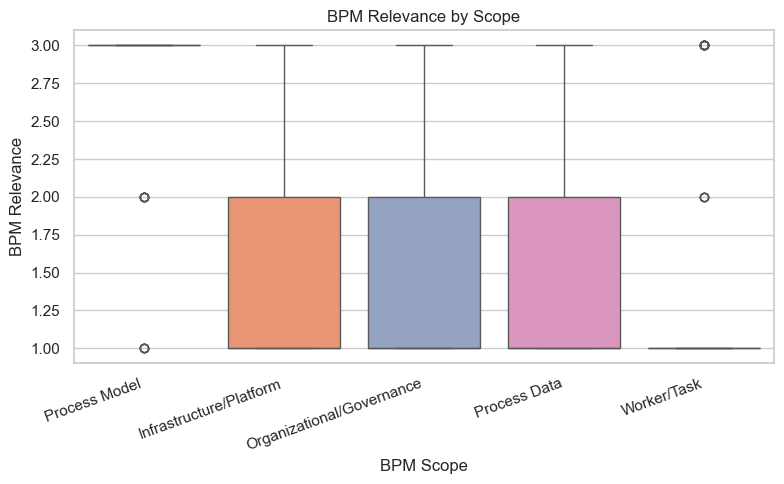

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
order = scope_exploded.groupby("BPM Scope")["BPM Relevance"].median().sort_values(ascending=False).index
sns.boxplot(data=scope_exploded, x="BPM Scope", y="BPM Relevance", order=order, ax=ax, palette="Set2")
ax.set_title("BPM Relevance by Scope")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Top-rated guidelines

The highest-relevance guidelines across all sources — useful as a starting shortlist for
whatever comes next (e.g. seeding the real interview, or picking candidates for a BPMN pattern
library).


In [11]:
top = (
    df.sort_values("BPM Relevance", ascending=False)
    .loc[:, ["Source", "ID", "Name", "BPM Relevance", "BPM Scope", "Generic"]]
    .head(20)
    .reset_index(drop=True)
)
top


,Source,ID,Name,BPM Relevance,BPM Scope,Generic
0,lean,LEAN.CI.2,Environmental Checklist in Process Review Events,3,"Process Model, Organizational/Governance",No
1,aws,AWS.Region.1,Choose Region based on both business requirements and sustainability goals,3,Infrastructure/Platform,Yes
2,aws,AWS.Demand.1,Scale workload infrastructure dynamically,3,"Worker/Task, Infrastructure/Platform",No
3,aws,AWS.Demand.2,Align SLAs with sustainability goals,3,Organizational/Governance,No
4,lean,LEAN.CI.1,Evaluate Environmental Impact in Every Process Improvement,3,"Process Model, Worker/Task",No
5,gbpp,GBPP.PROC.1,Common Process Improvement for Environmental Aspects,3,"Process Model, Worker/Task",No
6,gbpp,GBPP.BASIC.3,Resource Change,3,"Worker/Task, Infrastructure/Platform",No
7,gbpp,GBPP.BASIC.2,Green Variant,3,"Process Model, Worker/Task",No
8,gbpp,GBPP.BASIC.1,Green Compensation,3,Process Model,No
9,w3c,W3C.BIZ.26,Create a business continuity and disaster recovery plan,3,"Process Model, Organizational/Governance",No


## Persona comparison: general vs. sustainability-expert vs. BPM-expert

The `survey_claude.csv` pass above has no persona framing. Two more full passes exist over the
same 425 guidelines, each Claude prompted to adopt a specific expert persona:

- **`survey_claude_sustainability.csv`** (`RespondentID` = `claude-sustainability`) — a senior
  sustainability/green-IT consultant with only lay BPM exposure. Tends to project real
  environmental value onto anything touching systems/operations, and applies BPM Scope/Lifecycle
  vocabulary more loosely since that isn't their home turf.
- **`survey_claude_bpm.csv`** (`RespondentID` = `claude-bpm`) — a senior BPM
  consultant/architect with only lay sustainability exposure. Precise and conservative about
  Scope/Lifecycle classification, but dismisses guidelines whose value is "just good for the
  planet" without a direct structural tie to process design/execution/governance.

This is **test/comparison data**, not a real human survey — it previews where those two
perspectives are likely to disagree, ahead of the actual internal expert survey with envite
Consulting. See `generate_analysis_json.py`'s `round` argument and `analysis.js`'s
`ANALYSIS_ROUNDS` for how this feeds the frontend's three-tab analysis page.

In [12]:
def load_persona(source, persona):
    survey_path = GUIDELINES_DIR / source / f"survey_claude_{persona}.csv"
    survey = pd.read_csv(survey_path, encoding="utf-8-sig")
    survey["Source"] = source
    return survey

sustainability_df = pd.concat([load_persona(s, "sustainability") for s in SOURCES], ignore_index=True)
bpm_df = pd.concat([load_persona(s, "bpm") for s in SOURCES], ignore_index=True)

for frame in (sustainability_df, bpm_df):
    frame["BPM Relevance"] = pd.to_numeric(frame["BPM Relevance"], errors="coerce")

# One row per guideline, one relevance column per pass, for direct comparison.
compare = (
    df[["Source", "ID", "Name", "BPM Relevance"]]
    .rename(columns={"BPM Relevance": "General"})
    .merge(sustainability_df[["ID", "BPM Relevance"]].rename(columns={"BPM Relevance": "Sustainability"}), on="ID")
    .merge(bpm_df[["ID", "BPM Relevance"]].rename(columns={"BPM Relevance": "BPM"}), on="ID")
)
compare["Sustainability - BPM"] = compare["Sustainability"] - compare["BPM"]

print(f"{len(compare)} guidelines with all three passes")
compare.head()


425 guidelines with all three passes


,Source,ID,Name,General,Sustainability,BPM,Sustainability - BPM
0,aws,AWS.Region.1,Choose Region based on both business requirements and sustainability goals,3,3,1,2
1,aws,AWS.Demand.1,Scale workload infrastructure dynamically,3,2,3,-1
2,aws,AWS.Demand.2,Align SLAs with sustainability goals,3,2,3,-1
3,aws,AWS.Demand.3,Stop the creation and maintenance of unused\r\n assets,1,2,1,1
4,aws,AWS.Demand.4,Optimize geographic placement of workloads based on their networking require...,1,2,1,1


General         mean=1.19  dist={0: 95, 1: 223, 2: 38, 3: 69}
Sustainability  mean=1.73  dist={0: 8, 1: 167, 2: 180, 3: 70}
BPM             mean=0.88  dist={0: 210, 1: 111, 2: 51, 3: 53}

Mean |Sustainability - BPM|: 1.04
Exact agreement: 15%
Max-spread (|diff|>=2) disagreements: 80 of 425


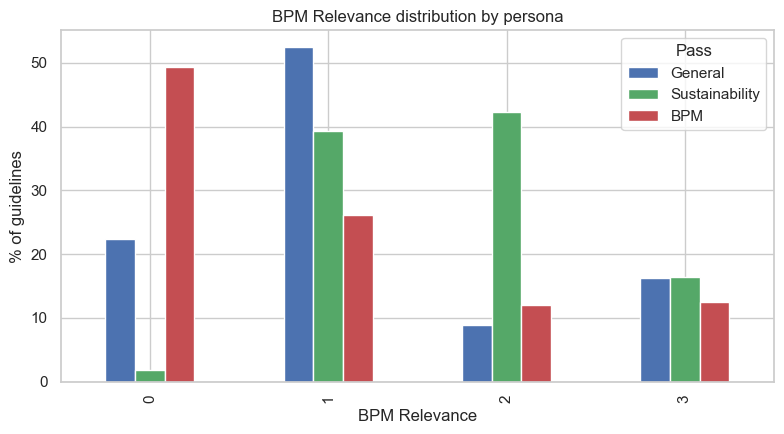

In [13]:
passes = {"General": compare["General"], "Sustainability": compare["Sustainability"], "BPM": compare["BPM"]}
for name, vals in passes.items():
    print(f"{name:15s} mean={vals.mean():.2f}  dist={vals.value_counts().sort_index().to_dict()}")

diffs = (compare["Sustainability"] - compare["BPM"]).abs()
print(f"\nMean |Sustainability - BPM|: {diffs.mean():.2f}")
print(f"Exact agreement: {(diffs == 0).mean() * 100:.0f}%")
print(f"Max-spread (|diff|>=2) disagreements: {(diffs >= 2).sum()} of {len(diffs)}")

dist_by_pass = pd.DataFrame({name: vals.value_counts(normalize=True).sort_index() * 100 for name, vals in passes.items()})
ax = dist_by_pass.reindex([0, 1, 2, 3]).plot(kind="bar", figsize=(8, 4.5), color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_title("BPM Relevance distribution by persona")
ax.set_xlabel("BPM Relevance")
ax.set_ylabel("% of guidelines")
ax.legend(title="Pass")
plt.tight_layout()
plt.show()


### Where the two personas disagree most

Sorted by `Sustainability - BPM` - positive means the sustainability persona rated it higher,
negative means the BPM persona did.

In [14]:
top_divergent = (
    compare.reindex(compare["Sustainability - BPM"].abs().sort_values(ascending=False).index)
    .head(15)
    .loc[:, ["Source", "ID", "Name", "General", "Sustainability", "BPM", "Sustainability - BPM"]]
    .reset_index(drop=True)
)
top_divergent

,Source,ID,Name,General,Sustainability,BPM,Sustainability - BPM
0,aws,AWS.HWS.2,Use instance types with the least impact,1,3,0,3
1,gsf,GSF.DEV.24,Use right-sized and energy-efficient AI models,0,3,0,3
2,lean,LEAN.DESIGN.2,"Weigh Lifecycle and Health Impact, Not Just Volume",1,3,0,3
3,aws,AWS.HWS.4,Optimize your use of hardware-based compute accelerators,0,2,0,2
4,lean,LEAN.DESIGN.1,Involve Environmental Expertise Early in Process Redesign,2,3,1,2
5,gbpp,GBPP.BASIC.3,Resource Change,3,3,1,2
6,w3c,W3C.UX.3,Integrate sustainability into every stage of the ideation process,1,3,1,2
7,w3c,W3C.UX.1,"Identify, assess, disclose, review, and mitigate sustainability impacts",2,3,1,2
8,w3c,W3C.WEBDEV.11,Use sustainable JavaScript and APIs,0,2,0,2
9,w3c,W3C.WEBDEV.10,Ensure layouts work for different devices and requirements,1,2,0,2


## Claude vs. human ratings (stub — activates once `survey.csv` is filled in)

Right now every source's `survey.csv` is empty (header-only), reserved for the real interview
pass. Once it has data, re-run this cell: it merges the human ratings against
`survey_claude.csv` on `ID` and reports agreement.


In [15]:
def load_human_survey(source):
    path = GUIDELINES_DIR / source / "survey.csv"
    human = pd.read_csv(path, encoding="utf-8-sig")
    human = human.dropna(subset=["BPM Relevance"])
    human.insert(0, "Source", source)
    return human

human_frames = [load_human_survey(s) for s in SOURCES]
human_df = pd.concat(human_frames, ignore_index=True) if human_frames else pd.DataFrame()

if human_df.empty:
    print("No human ratings yet - every source's survey.csv only has the header row.")
    print("Once ratings exist (one row per (RespondentID, ID) pair - see SURVEY_SCHEMA.md),")
    print("this cell will merge them against respondents.csv (for BPM/sustainability")
    print("experience and role) and against survey_claude.csv on ID, and report agreement")
    print("(mean absolute difference, exact-agreement %, and a breakdown by respondent")
    print("experience) between the human interview and the Claude pass.")
else:
    respondents_df = pd.read_csv(REPO_ROOT / "respondents.csv", encoding="utf-8-sig")
    human_df = human_df.merge(respondents_df, on="RespondentID", how="left")
    human_df["BPM Relevance"] = pd.to_numeric(human_df["BPM Relevance"], errors="coerce")

    claude_df = df[["Source", "ID", "BPM Relevance", "BPM Scope", "Generic"]].rename(
        columns={"BPM Relevance": "Claude Relevance", "BPM Scope": "Claude Scope", "Generic": "Claude Generic"}
    )
    compare = human_df.merge(claude_df, on=["Source", "ID"], how="inner")
    compare["Abs Diff"] = (compare["BPM Relevance"] - compare["Claude Relevance"]).abs()

    print(f"{len(compare)} human ratings (from {human_df['RespondentID'].nunique()} respondent(s)) have a matching Claude rating.")
    print(f"Mean absolute difference in BPM Relevance: {compare['Abs Diff'].mean():.2f}")
    print(f"Exact agreement: {(compare['Abs Diff'] == 0).mean() * 100:.1f}%")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.scatterplot(data=compare, x="Claude Relevance", y="BPM Relevance", hue="Source", ax=axes[0])
    axes[0].plot([0, 3], [0, 3], linestyle="--", color="gray")
    axes[0].set_title("Human vs. Claude BPM Relevance")

    experience_order = [
        "None", "Studied it, not in practice", "Practitioner, < 2 years",
        "Practitioner, 2-5 years", "Practitioner, 5+ years", "Prefer not to say",
    ]
    present_order = [e for e in experience_order if e in compare["BPM Experience"].unique()]
    sns.boxplot(data=compare, x="BPM Experience", y="Abs Diff", order=present_order, ax=axes[1], palette="Set2")
    axes[1].set_title("Agreement with Claude by rater's BPM experience")
    axes[1].set_ylabel("Abs Diff vs. Claude Relevance")
    plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right")

    plt.tight_layout()
    plt.show()

No human ratings yet - every source's survey.csv only has the header row.
Once ratings exist (one row per (RespondentID, ID) pair - see SURVEY_SCHEMA.md),
this cell will merge them against respondents.csv (for BPM/sustainability
experience and role) and against survey_claude.csv on ID, and report agreement
(mean absolute difference, exact-agreement %, and a breakdown by respondent
experience) between the human interview and the Claude pass.
